In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
# sklearn aka scikitlearn
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format

In [2]:
qSales = pd.read_csv('qSales_2024.csv')

display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [3]:
apple_sales = qSales.loc[qSales['tic']=='AAPL']

display(apple_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A


In [4]:
#Step 0 - make sure the date is recognized as a date - important during regression especially
# time series regression
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

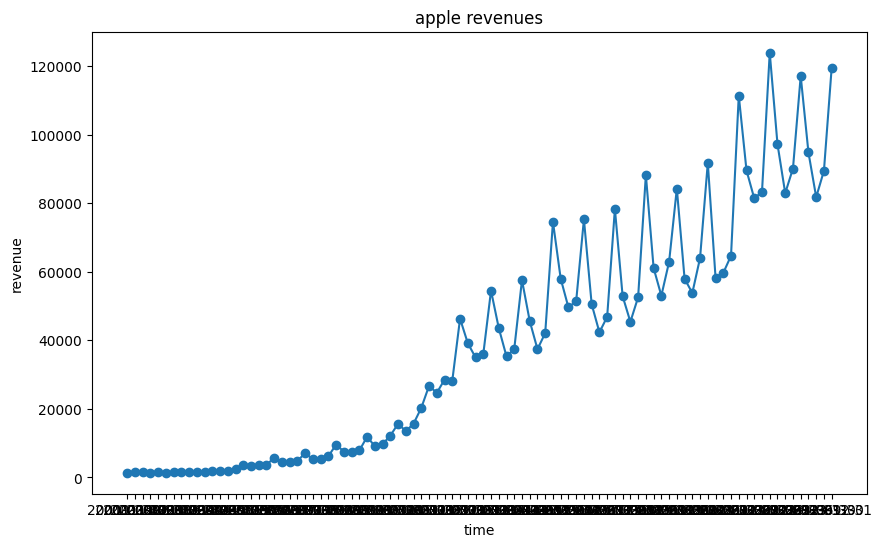

In [5]:
#step 1 - always visualize the data

plt.figure(figsize=(10,6))

plt.title('apple revenues')

plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(apple_sales['datadate'],apple_sales['saleq'], marker='o')

#time series forecasting is just using time as an independent variable to calculate our dependent variable

In [6]:
#step 1 is to incorporate a new "time" column, which will measure time periods
# similar to how in accounting and fiance you use Time 1, time 2, etc.
# we want our time column to have the time period number, so 1, 2, 3, etc. etc

apple_sales['time'] = range(1, len(apple_sales) + 1)

apple_sales

/tmp/ipykernel_4353/2291578352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['time'] = range(1, len(apple_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91


In [7]:
# this snippet of code splits datasets into 75% and 25%

dt4training = apple_sales[:int(0.75 * len(apple_sales))]

#this command will take everything AFTER the first 75% of rows - take colon to the end
dt4testing = apple_sales[int(0.75 * len(apple_sales)):]

display(dt4training)
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1690,2017-03-31,2017,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q1,2017Q2,52896.00,A,65
65,1690,2017-06-30,2017,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q2,2017Q3,45408.00,A,66
66,1690,2017-09-30,2017,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q3,2017Q4,52579.00,A,67
67,1690,2017-12-31,2018,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q4,2018Q1,88293.00,A,68


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
69,1690,2018-06-30,2018,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q2,2018Q3,53029.00,A,70
70,1690,2018-09-30,2018,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q3,2018Q4,62900.00,A,71
71,1690,2018-12-31,2019,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q4,2019Q1,84310.00,A,72
72,1690,2019-03-31,2019,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q1,2019Q2,58015.00,A,73
73,1690,2019-06-30,2019,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q2,2019Q3,53809.00,A,74
74,1690,2019-09-30,2019,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q3,2019Q4,64040.00,A,75
75,1690,2019-12-31,2020,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q4,2020Q1,91819.00,A,76
76,1690,2020-03-31,2020,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q1,2020Q2,58313.00,A,77
77,1690,2020-06-30,2020,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q2,2020Q3,59685.00,A,78
78,1690,2020-09-30,2020,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q3,2020Q4,64698.00,A,79


In [8]:
#first prepare the independent variable in our case thats just time
# second, prepare the dependent variable - revenue
# fit the model
# forecast values for our testing set

x = dt4training.loc[:,'time']
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,-13536.82
time,1077.61


# apple revenue = -13,536 + 1,077 * time

In [9]:
x_test = dt4testing.loc[:,'time']
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
69,61895.57
70,62973.18
71,64050.78
72,65128.39
73,66206.00
74,67283.60
75,68361.21
76,69438.81
77,70516.42
78,71594.02


In [10]:
# how to make python give you a range of predicted values rather than a specific one
# following code to get a range of predictions
# 1 - alpha = confidence level

model1.get_prediction(x_test).summary_frame(alpha=0.2) # confidence level of 80%
#model1.get_prediction(x_test).summary_frame(alpha=0.1) # confidence level of 90%

#pay attention to the OBS_ci_lower and upper figures and the mean, NOT MEAN_SE

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
69,61895.57,2457.90,58714.28,65076.87,48444.42,75346.72
70,62973.18,2511.13,59722.99,66223.37,49505.57,76440.79
71,64050.78,2564.70,60731.25,67370.32,50566.27,77535.30
72,65128.39,2618.61,61739.09,68517.69,51626.53,78630.25
73,66206.00,2672.82,62746.53,69665.46,52686.35,79725.64
74,67283.60,2727.32,63753.59,70813.61,53745.74,80821.47
75,68361.21,2782.09,64760.31,71962.10,54804.69,81917.73
76,69438.81,2837.11,65766.69,73110.93,55863.20,83014.43
77,70516.42,2892.38,66772.77,74260.07,56921.28,84111.56
78,71594.02,2947.88,67778.54,75409.50,57978.93,85209.12


In [14]:
apple_sales['release_dummy_variable'] = np.where(apple_sales['fqtr']==1,1,0)
apple_sales['release_dummy_interaction'] = apple_sales['time'] * apple_sales['release_dummy_variable']
display(apple_sales)

# ['2022-12-31','2021-12-31']

/tmp/ipykernel_4353/3169260365.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['release_dummy_variable'] = np.where(apple_sales['fqtr']==1,1,0)
/tmp/ipykernel_4353/3169260365.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['release_dummy_interaction'] = apple_sales['time'] * apple_sales['release_dummy_variable']


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummy_interaction
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88,1,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89,0,0
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90,0,0
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91,0,0


In [15]:
dt4training = apple_sales[:int(0.75 * len(apple_sales))]

#this command will take everything AFTER the first 75% of rows - take colon to the end
dt4testing = apple_sales[int(0.75 * len(apple_sales)):]

In [16]:
dt4training

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummy_interaction
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1690,2017-03-31,2017,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q1,2017Q2,52896.00,A,65,0,0
65,1690,2017-06-30,2017,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q2,2017Q3,45408.00,A,66,0,0
66,1690,2017-09-30,2017,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q3,2017Q4,52579.00,A,67,0,0
67,1690,2017-12-31,2018,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2017Q4,2018Q1,88293.00,A,68,1,68


In [17]:
x = dt4training.loc[:,['time', 'release_dummy_variable','release_dummy_interaction']]
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,-11044.75
time,933.21
release_dummy_variable,-10422.13
release_dummy_interaction,578.33


# apple revenue = -11,044 + 933 * time + (-10,422) * release_dummy_variable + 578 * release_dummy_interaction

release_dummy_interaction = time * dummy variable

In [19]:
x_test = dt4testing.loc[:,['time','release_dummy_variable','release_dummy_interaction']]
x_test = sm.add_constant(x_test)

model1.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
69,54280.00,2160.94,51482.20,57077.80,43950.72,64609.28
70,55213.21,2207.41,52355.25,58071.17,44867.47,65558.95
71,87363.94,3895.97,82319.78,92408.10,76214.50,98513.38
72,57079.63,2301.23,54100.21,60059.06,46699.68,67459.58
73,58012.84,2348.54,54972.16,61053.52,47615.14,68410.54
74,58946.05,2396.10,55843.80,62048.31,48530.18,69361.93
75,93410.10,4233.82,87928.53,98891.67,82056.07,104764.13
76,60812.48,2491.90,57586.18,64038.77,50358.99,71265.96
77,61745.69,2540.12,58456.96,65034.42,51272.76,72218.61
78,62678.90,2588.54,59327.48,66030.31,52186.12,73171.68


In [20]:
dt4testing

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummy_interaction
69,1690,2018-06-30,2018,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q2,2018Q3,53029.00,A,70,0,0
70,1690,2018-09-30,2018,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q3,2018Q4,62900.00,A,71,0,0
71,1690,2018-12-31,2019,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2018Q4,2019Q1,84310.00,A,72,1,72
72,1690,2019-03-31,2019,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q1,2019Q2,58015.00,A,73,0,0
73,1690,2019-06-30,2019,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q2,2019Q3,53809.00,A,74,0,0
74,1690,2019-09-30,2019,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q3,2019Q4,64040.00,A,75,0,0
75,1690,2019-12-31,2020,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2019Q4,2020Q1,91819.00,A,76,1,76
76,1690,2020-03-31,2020,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q1,2020Q2,58313.00,A,77,0,0
77,1690,2020-06-30,2020,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q2,2020Q3,59685.00,A,78,0,0
78,1690,2020-09-30,2020,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2020Q3,2020Q4,64698.00,A,79,0,0


#To forecast actual future values outside the dataset
Step 1: create synthetic future datasets for your time periods, dummy variables, and interaction terms

Step 2: do the exact same steps as testing your model, except use the synthetic data instead of the testing data

In [22]:
synth_data = pd.read_csv('synthetic_data.csv')
display(synth_data)

,time,release_dummy_variable,release_dummy_interaction
0,93,0,0
1,94,0,0
2,95,1,95
3,96,0,0
4,97,0,0
5,98,0,0
6,99,1,99
7,100,0,0
8,101,0,0
9,102,0,0


In [23]:
x_test = synth_data.loc[:,['time','release_dummy_variable','release_dummy_interaction']]
x_test = sm.add_constant(x_test)

model1.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,75743.85,3282.05,71494.53,79993.16,64930.75,86556.95
1,76677.06,3332.44,72362.50,80991.61,65838.15,87515.96
2,122129.34,5909.30,114478.50,129780.18,109583.36,134675.33
3,78543.48,3433.48,74098.11,82988.85,67651.84,89435.11
4,79476.69,3484.12,74965.76,83987.62,68558.13,90395.25
5,80409.90,3534.83,75833.31,84986.49,69464.05,91355.75
6,128175.50,6271.27,120056.01,136294.99,115338.35,141012.65
7,82276.32,3636.48,77568.13,86984.52,71274.80,93277.84
8,83209.53,3687.40,78435.41,87983.66,72179.63,94239.43
9,84142.74,3738.39,79302.60,88982.89,73084.11,95201.38
